#This Notebook is to visualize the weights of a model trained on mnist. The weights of the first layer were easy to visualize as each node took 784 inputs and weights. The weights could be reshaped into a 28x28 image. For other layers however it is more difficult as the nonlinearity kicks in. The pattern each node in the second layer onward picks on depends on which nodes in the previous layers fired. It is input dependent. For each input, we can construct a 28x28 image.

##Load the model

In [ ]:
# unzip snapshots.zip
!unzip snapshots.zip

In [ ]:
import torch

In [ ]:
 # print device
 device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 print(device)

cuda


In [ ]:
from torch import nn

In [ ]:
class Fully_Connected(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1 = nn.Linear(784, 784)
    self.l2 = nn.Linear(784, 784)
    self.l3 = nn.Linear(784, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    out = self.relu(out)
    out = self.l3(out)
    return out

In [ ]:
# load final model
model = Fully_Connected()
model.load_state_dict(torch.load('snapshots/epoch10_snap_final.pt'))
model.eval()

Fully_Connected(
  (l1): Linear(in_features=784, out_features=784, bias=True)
  (l2): Linear(in_features=784, out_features=784, bias=True)
  (l3): Linear(in_features=784, out_features=10, bias=True)
  (relu): ReLU()
)

##Visualizing weights

In [ ]:
# a function that returns the composed transformtion matrix based on input
def get_composed(model, layer, input, use_input=True):
  layers = list(model.children())
  output = torch.tensor(input).float().view(1, -1)
  for i in range(layer):
    mat, bias = layers[i].weight, layers[i].bias
    mat.requires_grad = False
    bias.requires_grad = False
    if i == 0:
      composed = mat# + bias.unsqueeze(1)
      comp_bias = bias
    elif use_input:
      output = torch.relu(output)
      composed = torch.matmul(mat * mask, composed)# + bias.unsqueeze(1)
      comp_bias = torch.matmul(mat * mask, comp_bias) + bias
    else:
      composed = torch.matmul(mat, composed)# + bias.unsqueeze(1)
      comp_bias = torch.matmul(mat, comp_bias) + bias

    if use_input:
      output = layers[i](output)
      mask = output > 0
      # output = torch.relu(output)
  print(output)
  return composed, comp_bias, output

Creating canvas for user to draw

In [ ]:
!pip install ipycanvas ipywidgets

In [ ]:
# to allow interactive widgets in colab, Ignore of you are running locally
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
from ipycanvas import Canvas, hold_canvas
from IPython.display import display
import ipywidgets as widgets

class interactive_canvas():
  def __init__(self, width_percent=25, height_percent=25):
    self.canvas = Canvas(width=28, height=28, sync_image_data=True)
    self.drawing = False

    canvas = self.canvas
    canvas.stroke_style = 'white'
    canvas.line_width = 1
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    # Draw as you move the mouse (mousedown + move = draw)
    canvas.on_mouse_down(self.on_mouse_down)
    canvas.on_mouse_up(self.on_mouse_up)
    canvas.on_mouse_move(self.on_mouse_move)
    # Display the canvas
    canvas.layout.width = f'{width_percent}%'
    canvas.layout.height = f'{height_percent}25%'

  def on_mouse_down(self, x, y):
    self.drawing = True
    # clear
    canvas = self.canvas
    canvas.clear()
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.begin_path()
    canvas.move_to(x, y)

  def on_mouse_up(self, x, y):
    self.drawing = False

  def on_mouse_move(self, x, y):
    if self.drawing:
      canvas = self.canvas
      with hold_canvas(canvas):
        canvas.line_to(x, y)
        canvas.stroke()

  def get_image_data(self):
    return self.canvas.get_image_data()

  def display(self):
    display(self.canvas)


canv = interactive_canvas()
canv.display()


Canvas(height=28, layout=Layout(height='2525%', width='25%'), sync_image_data=True, width=28)

In [ ]:
user_img = canv.get_image_data()[:, :, 0]
user_img = (user_img/255 > 0.5).astype(int)
# use the model to classify the user img
with torch.no_grad():
  output = model(torch.from_numpy(user_img).view(1, -1).float())
  prob = torch.softmax(output, dim=1)[0]
  max_prob = torch.argmax(prob)
  print(f"predicted number: {max_prob}")
  print(f"predicted probability: {prob[max_prob]}")

predicted number: 3
predicted probability: 1.0


In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'User image to black and white')

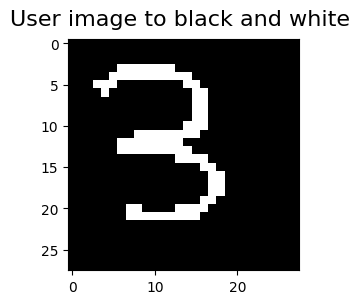

In [ ]:
# plot user image
fig, ax = plt.subplots(figsize=(3, 3))
plt.imshow(user_img, cmap='gray')
plt.suptitle('User image to black and white', fontsize=16)

Visualize some nodes in layer 2

In [ ]:
comp_2, bias_2, _ = get_composed(model, 2, user_img, use_input=True)

In [ ]:
# function to draw 9 elements from a matrix where rows are images
def draw_9_samples(matrix):
  idxs = np.linspace(0, len(matrix)-1, 9, dtype=int)
  # get min and max of all samples
  min_val, max_val = float('inf'), float('-inf')
  for i in idxs:
    min_val = min(min_val, matrix[i].min())
    max_val = max(max_val, matrix[i].max())

  fig, axs = plt.subplots(3, 3, figsize=(10, 10))
  for i in range(3):
    for j in range(3):
      axs[i, j].imshow(matrix[idxs[i*3+j]].view(28, 28).cpu().numpy(), cmap='seismic', vmin=min_val, vmax=max_val)
      # title
      axs[i, j].set_title(f"Node {idxs[i*3+j]}")

Text(0.5, 0.98, 'Nodes in layer 2, adjusted for user input in above canvas')

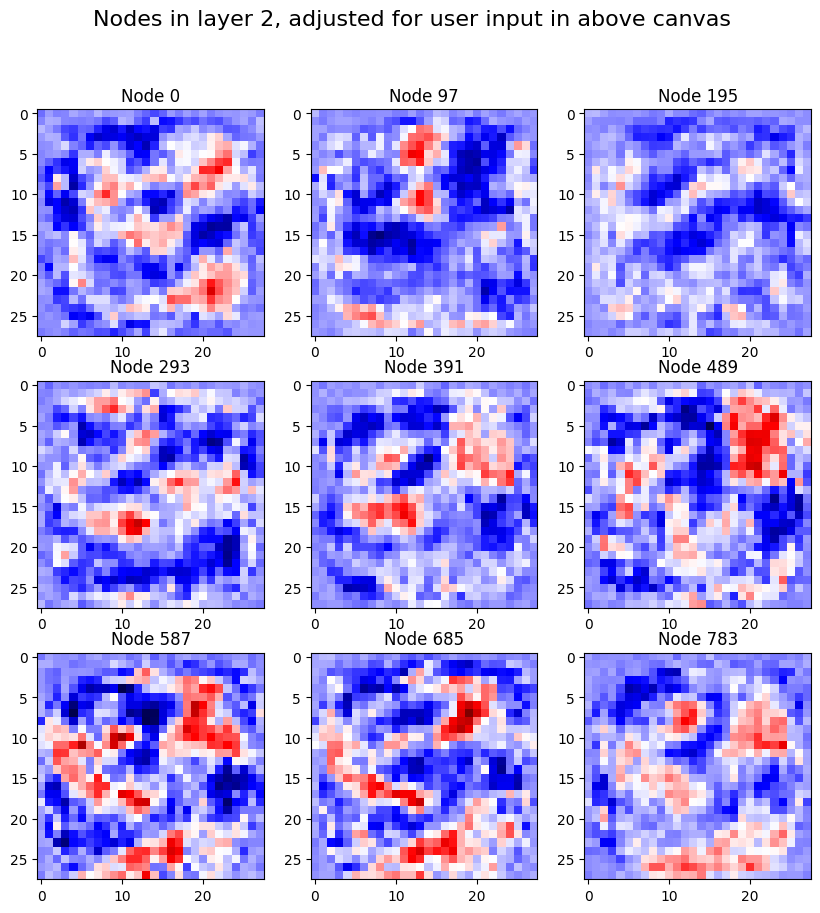

In [ ]:
draw_9_samples(comp_2)
plt.suptitle('Nodes in layer 2, adjusted for user input in above canvas', fontsize=16)

In [ ]:
comp_2, bias_2, _ = get_composed(model, 2, user_img, use_input=False)

Text(0.5, 0.98, 'Nodes in layer 2, composition of linear transformations regardless of input')

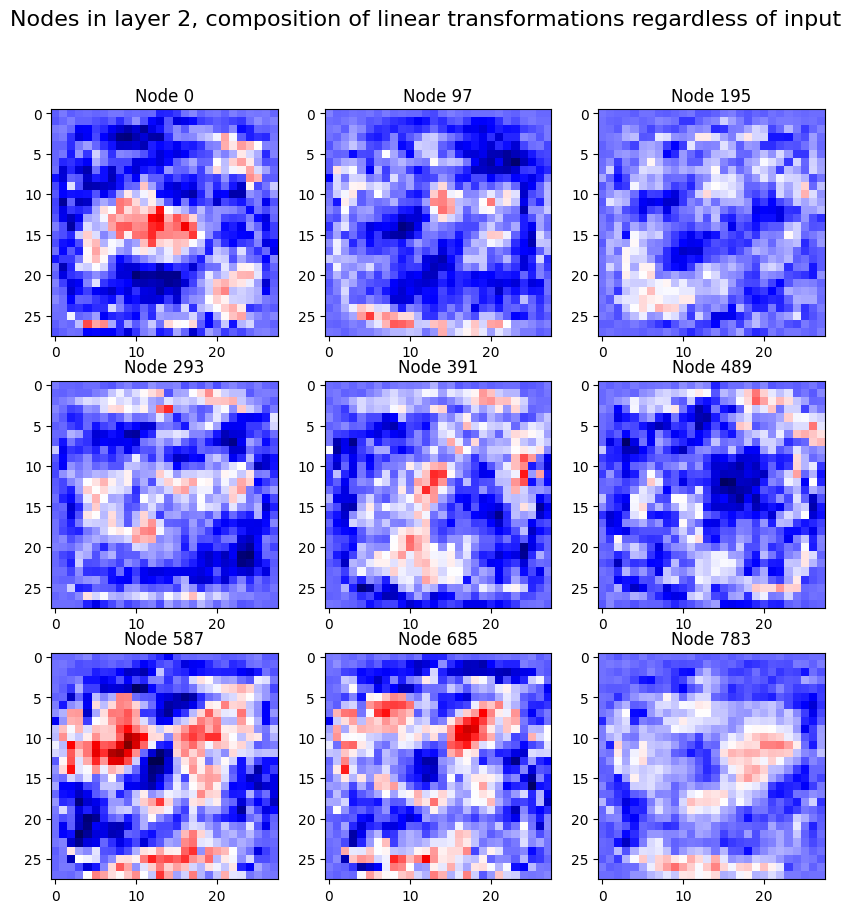

In [ ]:
draw_9_samples(comp_2)
plt.suptitle('Nodes in layer 2, composition of linear transformations regardless of input', fontsize=16)

Visualizing the last layer.

In [ ]:
comp_final, bias_final, _ = get_composed(model, 3, user_img, use_input=True)

tensor([[-27.0700, -10.0566,  -8.2007,  24.4606, -18.0297, -17.3990, -27.4766,
          -3.9733,  -5.6584, -23.3937]])


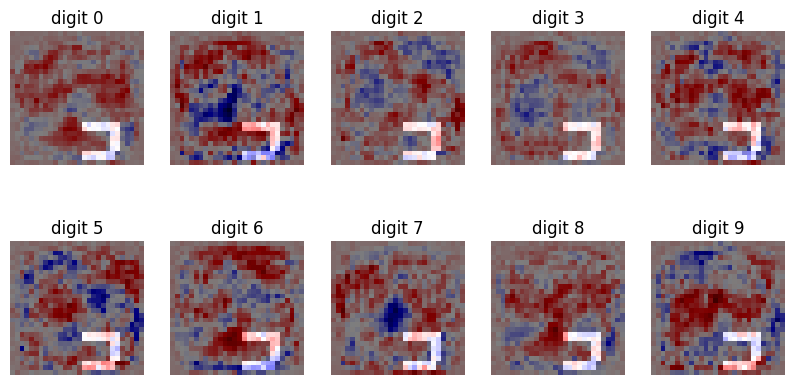

In [ ]:
# draw the ten matrices of the last layer
def draw_matrices(comp_final, user_img, output=None):
  fig, axs = plt.subplots(2, 5, figsize=(10, 5))
  flat_axes = axs.flatten()
  np_comp_final = comp_final.cpu().numpy()
  min_val, max_val = np_comp_final.min(), np_comp_final.max()
  for i in range(10):
    flat_axes[i].imshow(user_img, cmap='gray', alpha=1)
    flat_axes[i].imshow(np_comp_final[i].reshape(28, 28), cmap='seismic', alpha=0.5, vmin=min_val, vmax=max_val)
    if output is not None:
      flat_axes[i].set_title(f'digit {i}, logit: {output[i]:.2f}')
    else:
      flat_axes[i].set_title(f'digit {i}')
    flat_axes[i].axis('off')
draw_matrices(comp_final, user_img)

<BarContainer object of 10 artists>

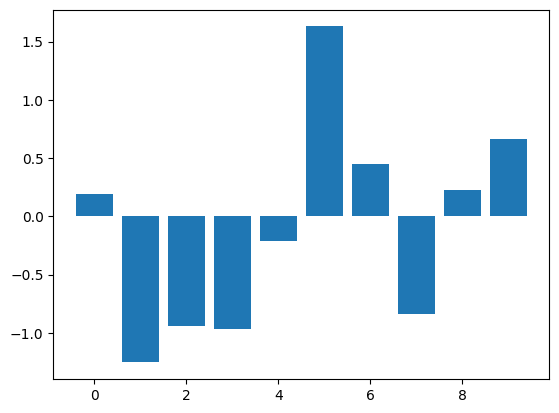

In [ ]:
# plotting the comp_bias
plt.bar(range(10), bias_final.cpu().numpy())

The contribution from the biases is minimal. around 1.5 max, whereas the contribution from the matrices is around 10-20.

In [ ]:
np_comp2 = comp_final.cpu().numpy()

In [ ]:
flat_user = user_img.flatten()

In [ ]:
import numpy as np

In [ ]:
np.matmul(np_comp2, flat_user)

array([-11.09018659,  -1.83249683,  -1.97046545,   2.58128467,
        -2.98904254,  -2.25625683, -17.85347839,   0.30810592,
        -7.12764083,  -1.00439765])

In [ ]:
from ipywidgets import Button, Layout

In [ ]:
import io
import contextlib
from ipywidgets import Label
from ipywidgets import Button, HBox, VBox, Output

In [ ]:
# Create canvas and widgets
canvas2 = interactive_canvas(100, 100)

button = Button(
    description='Process Drawing',
    layout=Layout(width='150px', height='40px')
)
plot_output = Output()

# Processing function: converts canvas to grayscale and plots it
def process_drawing(_):
  user_img = canvas2.get_image_data()[:, :, 0]
  user_img = (user_img/255 > 0.5).astype(int)
  # Suppress stdout from get_composed
  with io.StringIO() as buf, contextlib.redirect_stdout(buf):
      comp_final, bias_final, model_out = get_composed(model, 3, user_img, use_input=True)
  with plot_output:
      plot_output.clear_output()
      draw_matrices(comp_final, user_img, output=model_out[0])
      plt.tight_layout()
      plt.show()

  # change label
  label.value = f"predicted digit: {model_out.argmax()}"

button.on_click(process_drawing)

# Layout: canvas on the left, plot on the right, button on top

label = Label(value=f"")
vbox = VBox([canvas2.canvas, button, label], layout=Layout(width='25%', height='25%'))
ui = HBox([vbox, plot_output])
# ui = VBox([canvas2.canvas, button])
display(ui)
